In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
import shap
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    precision_score, 
    recall_score, 
    f1_score
)

c:\git\datascience-capstone\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# custom functions

def sentinel_divide(n, d):
    sentinel = -1
    safe_d = np.where(d == 0, sentinel, d)
    return n / safe_d

### Using the Preprocessed Minimal NFI dataset
This includes all 89 original elements because XGBoost can handle the sparsity.

In [3]:
df = pd.read_parquet("../../../data/processed/preprocessed_minimal.parquet")
df.shape

(2294985, 94)

In [4]:
# NFI column sort
nfi_meta = ['stub_id', 'particle_id', 'class', 'label', 'target']
element_cols = [c for c in df.columns if c not in nfi_meta]
gsr = ['pb', 'sb', 'ba']
non_gsr = sorted([c for c in element_cols if c not in gsr])
nfi_df = df[nfi_meta + gsr + non_gsr]

print(f"# of elements: {len(element_cols)}")

# of elements: 89


In [5]:
nfi_df.columns

Index(['stub_id', 'particle_id', 'class', 'label', 'target', 'pb', 'sb', 'ba',
       'ac', 'ag', 'al', 'ar', 'as', 'at', 'au', 'b', 'bi', 'br', 'ca', 'cd',
       'ce', 'cl', 'co', 'cr', 'cs', 'cu', 'dy', 'er', 'eu', 'f', 'fe', 'fr',
       'ga', 'gd', 'ge', 'hf', 'hg', 'ho', 'i', 'in', 'ir', 'k', 'kr', 'la',
       'lu', 'mg', 'mn', 'mo', 'n', 'na', 'nb', 'nd', 'ne', 'ni', 'np', 'o',
       'os', 'p', 'pa', 'pd', 'pm', 'po', 'pr', 'pt', 'pu', 'ra', 'rb', 're',
       'rh', 'rn', 'ru', 's', 'sc', 'se', 'si', 'sm', 'sn', 'sr', 'ta', 'tb',
       'tc', 'te', 'th', 'ti', 'tl', 'tm', 'u', 'v', 'w', 'xe', 'y', 'yb',
       'zn', 'zr'],
      dtype='str')

### Re-engineer Features

In [6]:
eng_df = nfi_df.copy()

In [7]:
# Pb * Sb
eng_df['pb_times_sb'] = eng_df['pb'] * (eng_df['sb'])

In [8]:
# Log (Pb + Sb)
# eng_df['log_pb_plus_sb'] = np.log1p(eng_df['pb'] + eng_df['sb'])

In [9]:
# GSR ratios over total mass
total_mass = eng_df[element_cols].sum(axis=1)
total_mass_no_sb = total_mass - eng_df['sb']
total_mass_no_ba = total_mass - eng_df['ba']
total_mass_no_pb = total_mass - eng_df['pb']

# eng_df['pb_ba_over_non_sb_mass'] = (eng_df['pb'] + eng_df['ba']) / total_mass_no_sb
eng_df['pb_sb_over_non_ba_mass'] =  (eng_df['pb'] + eng_df['sb']) / total_mass_no_ba
eng_df['ba_sb_over_non_pb_mass'] =  (eng_df['ba'] + eng_df['sb']) / total_mass_no_pb

In [10]:
# Brass particles
eng_df['cu_zn_over_mass'] =  (eng_df['cu'] + eng_df['zn']) / total_mass

# Titanium Zinc
eng_df['ti_zn_over_mass'] = (eng_df['ti'] + eng_df['zn']) / total_mass

In [11]:
# Non-Barium GSR over Non-Barium Confounders
gsr = eng_df['pb'] + eng_df['sb']
confounders = eng_df['ca'] + eng_df['si'] + eng_df['al'] + eng_df['fe'] #+ eng_df['ti'] + eng_df['zn'] + eng_df['cu']
eng_df['gsr_over_confounders'] = sentinel_divide(gsr.values, confounders.values)

# check for any 'NaN' or 'inf'
any(np.isinf(eng_df['gsr_over_confounders']) | eng_df['gsr_over_confounders'].isna())

False

In [12]:
eng_df.columns

Index(['stub_id', 'particle_id', 'class', 'label', 'target', 'pb', 'sb', 'ba',
       'ac', 'ag', 'al', 'ar', 'as', 'at', 'au', 'b', 'bi', 'br', 'ca', 'cd',
       'ce', 'cl', 'co', 'cr', 'cs', 'cu', 'dy', 'er', 'eu', 'f', 'fe', 'fr',
       'ga', 'gd', 'ge', 'hf', 'hg', 'ho', 'i', 'in', 'ir', 'k', 'kr', 'la',
       'lu', 'mg', 'mn', 'mo', 'n', 'na', 'nb', 'nd', 'ne', 'ni', 'np', 'o',
       'os', 'p', 'pa', 'pd', 'pm', 'po', 'pr', 'pt', 'pu', 'ra', 'rb', 're',
       'rh', 'rn', 'ru', 's', 'sc', 'se', 'si', 'sm', 'sn', 'sr', 'ta', 'tb',
       'tc', 'te', 'th', 'ti', 'tl', 'tm', 'u', 'v', 'w', 'xe', 'y', 'yb',
       'zn', 'zr', 'pb_times_sb', 'pb_sb_over_non_ba_mass',
       'ba_sb_over_non_pb_mass', 'cu_zn_over_mass', 'ti_zn_over_mass',
       'gsr_over_confounders'],
      dtype='str')

In [13]:
eng_cols = [c for c in eng_df.columns if c not in nfi_meta + element_cols]
print(f"# of engineered features: {len(eng_cols)}")
print(f"\nEngineered features:")
for feat in eng_cols:
    print(f"\t{feat}")

# of engineered features: 6

Engineered features:
	pb_times_sb
	pb_sb_over_non_ba_mass
	ba_sb_over_non_pb_mass
	cu_zn_over_mass
	ti_zn_over_mass
	gsr_over_confounders


__6 engineered features + 89 raw element features__

In [14]:
feature_cols = element_cols + eng_cols
print(f"# of feature columns: {len(feature_cols)}")

# of feature columns: 95


### Group aware train/test/val split 

Two-stage GroupShuffleSplit:
1. Split off 20% test (by stub_id)
2. From the remaining 80%, split off 25% as val (= 20% of total)

Result: ~60% train, ~20% val, ~20% test. No stub overlap between any pair.

In [15]:
X = eng_df[feature_cols].values.astype(np.float32)
y = eng_df['target'].values.astype(np.float32)
groups = eng_df['stub_id'].values

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
trainval_idx, test_idx = next(gss1.split(X, y, groups))

X_trainval, X_test = X[trainval_idx], X[test_idx]
y_trainval, y_test = y[trainval_idx], y[test_idx]
groups_trainval = groups[trainval_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)  # 25% of 80% = 20% of total
train_idx_rel, val_idx_rel = next(gss2.split(X_trainval, y_trainval, groups_trainval))

X_train = X_trainval[train_idx_rel]
X_val = X_trainval[val_idx_rel]
y_train = y_trainval[train_idx_rel]
y_val = y_trainval[val_idx_rel]

groups_train = set(groups_trainval[train_idx_rel])
groups_val = set(groups_trainval[val_idx_rel])
groups_test = set(groups[test_idx])

In [16]:
# Verify no stub leakage
assert len(groups_train & groups_val) == 0, 'Train-Val stub leak!'
assert len(groups_train & groups_test) == 0, 'Train-Test stub leak!'
assert len(groups_val & groups_test) == 0, 'Val-Test stub leak!'

print("No stub-level leakage")

No stub-level leakage


Summarize the train/val/test split

In [17]:
total_obs = len(y_train) + len(y_val) + len(y_test)

summary = pd.DataFrame({
    "Split":         ["Train",          "Val",          "Test"],
    "Observations":  [len(y_train),     len(y_val),     len(y_test)],
    "% of Total":    [len(y_train)/total_obs*100, len(y_val)/total_obs*100, len(y_test)/total_obs*100],
    "GSR (target=1)":[int(y_train.sum()), int(y_val.sum()), int(y_test.sum())],
    "GSR %":         [y_train.mean()*100, y_val.mean()*100, y_test.mean()*100],
    "Unique Stubs":  [len(groups_train), len(groups_val), len(groups_test)],
})

summary["% of Total"] = summary["% of Total"].map("{:.1f}%".format)
summary["GSR %"]      = summary["GSR %"].map("{:.2f}%".format)

print(f"Total observations : {total_obs:,}")
print(f"Total features     : {X_train.shape[1]}")
print(f"Total unique stubs : {len(groups_train | groups_val | groups_test):,}\n")
print(summary.to_string(index=False))

Total observations : 2,294,985
Total features     : 95
Total unique stubs : 3,786

Split  Observations % of Total  GSR (target=1)  GSR %  Unique Stubs
Train       1444147      62.9%          717835 49.71%          2271
  Val        407614      17.8%          151162 37.08%           757
 Test        443224      19.3%          209949 47.37%           758


# Final Baseline

Default threshold = 0.5

In [18]:
baseline = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.1,
    min_child_weight=5, reg_alpha=0.1, reg_lambda=1.0,
    subsample=0.8, colsample_bytree=0.8,
    tree_method='hist', eval_metric='aucpr',
    early_stopping_rounds=30, random_state=42, n_jobs=-1,
)

baseline.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=10
)

[0]	validation_0-aucpr:0.99865	validation_1-aucpr:0.99909
[10]	validation_0-aucpr:0.99995	validation_1-aucpr:0.99997
[20]	validation_0-aucpr:0.99998	validation_1-aucpr:0.99998
[30]	validation_0-aucpr:0.99999	validation_1-aucpr:0.99999
[40]	validation_0-aucpr:0.99999	validation_1-aucpr:1.00000
[50]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000
[60]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000
[70]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000
[80]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000
[90]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000
[99]	validation_0-aucpr:1.00000	validation_1-aucpr:1.00000


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",30
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

__Eval Baseline train & val learning curves__

In [19]:
results = baseline.evals_result()
train_aucpr = results['validation_0']['aucpr']
val_aucpr = results['validation_1']['aucpr']

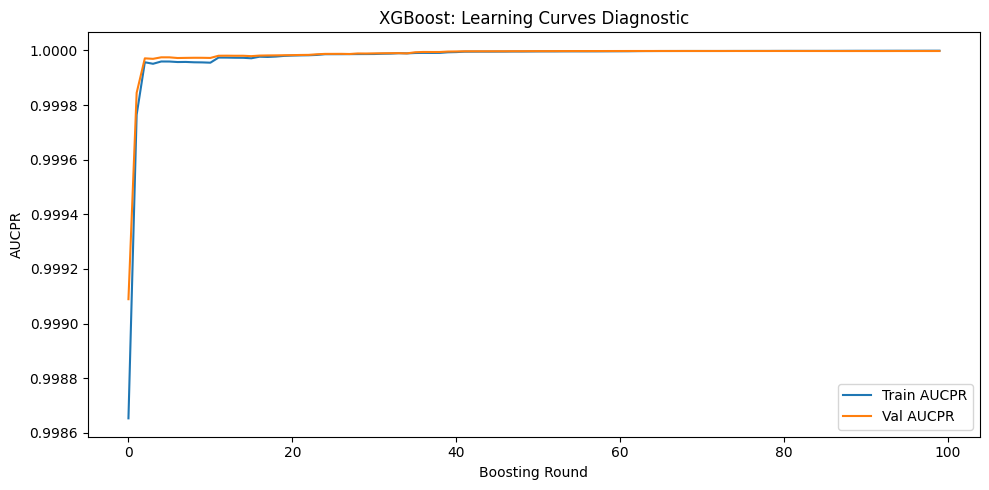

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(train_aucpr, label='Train AUCPR')
ax.plot(val_aucpr, label='Val AUCPR')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('AUCPR')
ax.set_title('XGBoost: Learning Curves Diagnostic')
ax.legend()
plt.tight_layout()
plt.savefig('xgb_learning_curves_final.png', dpi=150)
plt.show()

In [21]:
# Feature Importance
importances = baseline.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)
print(f"Final Baseline: Top 20 Important Features\n\n{feat_imp.head(20)}")

Final Baseline: Top 20 Important Features

pb_sb_over_non_ba_mass    0.642439
pb                        0.129808
gsr_over_confounders      0.085263
sb                        0.059660
pb_times_sb               0.045325
hg                        0.011675
mo                        0.010454
ba                        0.003728
ba_sb_over_non_pb_mass    0.002734
gd                        0.001544
zn                        0.000784
al                        0.000684
fe                        0.000601
si                        0.000580
as                        0.000537
ti_zn_over_mass           0.000483
cu_zn_over_mass           0.000482
cr                        0.000480
ca                        0.000475
cu                        0.000416
dtype: float32


### Evaluate against test

In [22]:
y_prob = baseline.predict_proba(X_test)[:, 1]
y_pred = baseline.predict(X_test)
# y_pred = (y_prob >= 0.94).astype(int)

y_prob_test = baseline.predict_proba(X_test)[:, 1]
y_pred_test = baseline.predict(X_test)
# y_pred_test = (y_prob_test >= 0.94).astype(int)

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_test)

# FP and FN breakdown
fp_mask = (y_pred_test == 1) & (y_test == 0)
fn_mask = (y_pred_test == 0) & (y_test == 1)

df_test = eng_df.iloc[test_idx]
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")
print(f"FPR: {fp/(fp+tn):.6f}")

print("\nFP by class:")
print(df_test['class'].loc[fp_mask].value_counts())
print("\nFN by class:")
print(df_test['class'].loc[fn_mask].value_counts())

# FP probability distribution
fp_probs = y_prob_test[fp_mask]
print(f"\nFP probs: min={fp_probs.min():.4f}, "
      f"median={np.median(fp_probs):.4f}, max={fp_probs.max():.4f}")

# Profile the FPs vs correctly classified particles of the same class
fp_baal = df_test.loc[fp_mask & (df_test['class'] == 'BaAl')]
tn_baal = df_test.loc[(y_pred_test == 0) & (y_test == 0) & (df_test['class'] == 'BaAl')]

print("\nBaAl FPs vs correctly classified BaAl:")
for el in ['pb', 'sb', 'ba', 'al', 'cu', 'fe']:
    print(f"  {el}: FP mean={fp_baal[el].mean():.2f}, "
          f"TN mean={tn_baal[el].mean():.2f}")

TN=233,068  FP=207  FN=45  TP=209,904
FPR: 0.000887

FP by class:
class
BaAl      148
BaCaSi     42
CuZn       12
TiZnGd      3
ZnTi        2
Name: count, dtype: int64

FN by class:
class
PbBa    29
BaSb    13
PbSb     3
Name: count, dtype: int64

FP probs: min=0.5017, median=0.7312, max=0.9990

BaAl FPs vs correctly classified BaAl:
  pb: FP mean=1.61, TN mean=0.00
  sb: FP mean=0.51, TN mean=0.01
  ba: FP mean=35.46, TN mean=31.41
  al: FP mean=11.99, TN mean=4.67
  cu: FP mean=8.08, TN mean=0.79
  fe: FP mean=2.34, TN mean=6.66


__Cross Validation__

In [23]:
cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)

cv_results = []
for fold, (tr_idx, va_idx) in enumerate(cv.split(X_trainval, y_trainval, groups_trainval)):
    model_cv = xgb.XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.1,
        min_child_weight=5, reg_alpha=0.1, reg_lambda=1.0,
        subsample=0.8, colsample_bytree=0.8,
        tree_method='hist', eval_metric='aucpr',
        early_stopping_rounds=30, random_state=42, n_jobs=-1,
    )
    model_cv.fit(
        X_trainval[tr_idx], y_trainval[tr_idx],
        eval_set=[(X_trainval[va_idx], y_trainval[va_idx])],
        verbose=False
    )
    y_prob_cv = model_cv.predict_proba(X_trainval[va_idx])[:, 1]
    y_pred_cv = model_cv.predict(X_trainval[va_idx])
    # y_pred_cv = (y_prob_cv >= 0.94).astype(int)

    pr_auc = average_precision_score(y_trainval[va_idx], y_prob_cv)
    roc_auc = roc_auc_score(y_trainval[va_idx], y_prob_cv)
    cm = confusion_matrix(y_trainval[va_idx], y_pred_cv)
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn)
    acc = (tp + tn) / (tp + tn + fp + fn)
    
    cv_results.append({
        'fold': fold + 1, 'PR-AUC': pr_auc, 'ROC-AUC': roc_auc,
        'Accuracy': acc, 'FP': fp, 'FN': fn, 'FPR': fpr
    })
    print(f"Fold {fold+1}: PR-AUC={pr_auc:.6f}, ROC-AUC={roc_auc:.6f}, "
          f"FP={fp}, FN={fn}, FPR={fpr:.6f}")

Fold 1: PR-AUC=0.999999, ROC-AUC=0.999999, FP=89, FN=105, FPR=0.000272
Fold 2: PR-AUC=0.999997, ROC-AUC=0.999998, FP=169, FN=108, FPR=0.000516
Fold 3: PR-AUC=0.999998, ROC-AUC=0.999998, FP=230, FN=105, FPR=0.000702


In [24]:
# Cross-Validation results
cv_df = pd.DataFrame(cv_results)
print("XGBoost final baseline cross validation results:\n")
print(f"Mean PR-AUC: {cv_df['PR-AUC'].mean():.6f} +/- {cv_df['PR-AUC'].std():.6f}")
print(f"Mean ROC-AUC: {cv_df['ROC-AUC'].mean():.6f} +/- {cv_df['ROC-AUC'].std():.6f}")
print(f"Mean FPR: {cv_df['FPR'].mean():.6f} +/- {cv_df['FPR'].std():.6f}")

XGBoost final baseline cross validation results:

Mean PR-AUC: 0.999998 +/- 0.000001
Mean ROC-AUC: 0.999998 +/- 0.000001
Mean FPR: 0.000497 +/- 0.000216


### Summary of Metrics

In [25]:
# === FULL TEST SET METRICS TABLE ===
# Compute test metrics
y_prob_test = baseline.predict_proba(X_test)[:, 1]
y_pred_test = baseline.predict(X_test)
# y_pred_test = (y_prob_test >= 0.94).astype(int)

cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()

metrics = {
    'Features': X_test.shape[1],
    'Accuracy': (tp + tn) / (tp + tn + fp + fn),
    'Precision (GSR)': precision_score(y_test, y_pred_test),
    'Recall (GSR)': recall_score(y_test, y_pred_test),
    'F1 (GSR)': f1_score(y_test, y_pred_test),
    'ROC-AUC': roc_auc_score(y_test, y_prob_test),
    'PR-AUC': average_precision_score(y_test, y_prob_test),
    'False Positives': fp,
    'FPR': fp / (fp + tn),
    'Early Stopping Round': baseline.best_iteration,
    'CV Mean PR-AUC': '0.999998 ± 0.000001',
    'CV Mean FPR': '0.000525 ± 0.000216',
}

metrics_df = pd.DataFrame({'Final Baseline': metrics})
print(metrics_df.to_string())

                           Final Baseline
Features                               95
Accuracy                         0.999431
Precision (GSR)                  0.999015
Recall (GSR)                     0.999786
F1 (GSR)                           0.9994
ROC-AUC                          0.999997
PR-AUC                           0.999997
False Positives                       207
FPR                              0.000887
Early Stopping Round                   69
CV Mean PR-AUC        0.999998 ± 0.000001
CV Mean FPR           0.000525 ± 0.000216


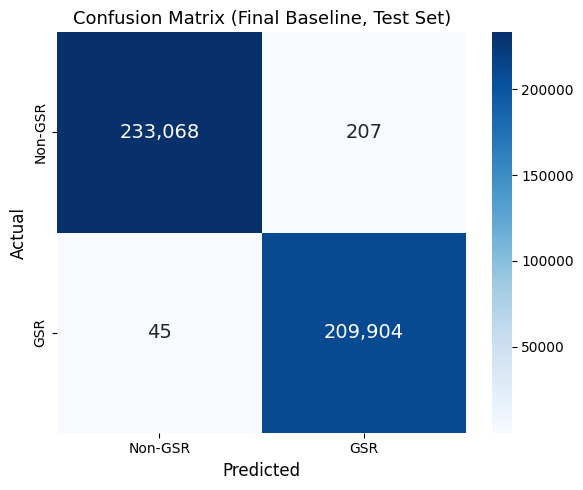

In [26]:
# === CONFUSION MATRIX HEATMAP ===
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm.reshape(2, 2), annot=True, fmt=',', cmap='Blues',
            xticklabels=['Non-GSR', 'GSR'],
            yticklabels=['Non-GSR', 'GSR'], ax=ax,
            annot_kws={'size': 14})
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix (Final Baseline, Test Set)', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix_final.png', dpi=150)
plt.show()

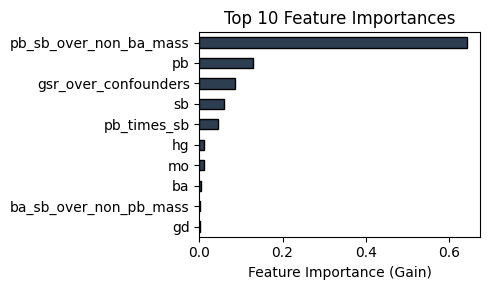

In [27]:
importances = baseline.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=True)

# Show top 10
top_n = feat_imp.tail(10)

fig, ax = plt.subplots(figsize=(5, 3))
top_n.plot(kind='barh', ax=ax, color='#2c3e50', edgecolor='black')
ax.set_xlabel('Feature Importance (Gain)')
ax.set_title('Top 10 Feature Importances')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

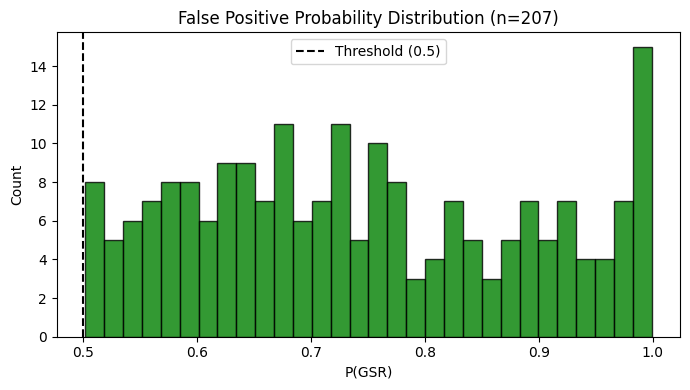

In [28]:
# === FP PROBABILITY DISTRIBUTION HISTOGRAM ===
fp_probs = y_prob_test[fp_mask]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(fp_probs, bins=30, color='green', edgecolor='black', alpha=0.8)
ax.axvline(x=0.5, color='black', linestyle='--', label='Threshold (0.5)')
ax.set_xlabel('P(GSR)')
ax.set_ylabel('Count')
ax.set_title(f'False Positive Probability Distribution (n={len(fp_probs)})')
ax.legend()
plt.tight_layout()
plt.savefig('fp_prob_dist.png', dpi=150)
plt.show()

### Recall on GSR subclasses / Specificity on Non-GSR subclasses

In [29]:
test_classes = eng_df['class'].values[test_idx]
test_labels = eng_df['label'].values[test_idx]
 
# Default-threshold predictions (already computed above as y_pred_test).
subclass_results = []
for cls in sorted(np.unique(test_classes)):
    mask = test_classes == cls
    n = mask.sum()
    if n < 10:
        continue
    label = test_labels[mask][0]
    cls_preds = y_pred_test[mask]
    cls_true  = y_test[mask]
    acc = (cls_preds == cls_true).mean()
    if label == 'GSR':
        rate = cls_preds.mean()              # recall = P(predicted=1 | actual=1)
        metric_name = 'Recall'
    else:
        rate = 1 - cls_preds.mean()           # specificity = P(predicted=0 | actual=0)
        metric_name = 'Specificity'
    subclass_results.append({
        'Class': cls, 'Label': label, 'N': int(n),
        'Accuracy': f'{acc:.4f}', metric_name: f'{rate:.4f}',
    })
 
subclass_df = pd.DataFrame(subclass_results)
print("Per-subclass performance (XGBoost, threshold=0.5):")
print(subclass_df.to_string(index=False))

Per-subclass performance (XGBoost, threshold=0.5):
 Class   Label      N Accuracy Specificity Recall
  BaAl Non_GSR  65221   0.9977      0.9977    NaN
BaCaSi Non_GSR  81503   0.9995      0.9995    NaN
  BaSb     GSR  20708   0.9994         NaN 0.9994
  CuZn Non_GSR  75472   0.9998      0.9998    NaN
GaCuSn Non_GSR    426   1.0000      1.0000    NaN
    Hg Non_GSR    678   1.0000      1.0000    NaN
  PbBa     GSR  48129   0.9994         NaN 0.9994
PbBaSb     GSR 108047   1.0000         NaN 1.0000
  PbSb     GSR  33065   0.9999         NaN 0.9999
TiZnGd Non_GSR   3434   0.9991      0.9991    NaN
  ZnTi Non_GSR   6541   0.9997      0.9997    NaN


### Threshold Optimization

In [30]:
val_prob = baseline.predict_proba(X_val)[:, 1]
test_prob = y_prob_test  # already computed above
 
def pick_thresholds(y_true, probs):
    """Returns (high_spec, balanced, high_sens) thresholds."""
    precisions, recalls, thresholds = precision_recall_curve(y_true, probs)
    f1s = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
    balanced_thr = thresholds[np.argmax(f1s)]
 
    high_spec_mask = precisions[:-1] >= 0.9999
    if high_spec_mask.any():
        idx = np.where(high_spec_mask)[0][np.argmax(recalls[:-1][high_spec_mask])]
        high_spec_thr = thresholds[idx]
    else:
        high_spec_thr = 0.99
 
    high_sens_mask = recalls[:-1] >= 0.999
    if high_sens_mask.any():
        idx = np.where(high_sens_mask)[0][np.argmax(precisions[:-1][high_sens_mask])]
        high_sens_thr = thresholds[idx]
    else:
        high_sens_thr = 0.01
    return high_spec_thr, balanced_thr, high_sens_thr
 
# Pick on val (forensically correct).
high_spec_val, balanced_val, high_sens_val = pick_thresholds(y_val, val_prob)
 
print("Thresholds picked on VAL (forensically honest):")
print(f"  High-specificity : {high_spec_val:.4f}")
print(f"  Balanced (F1)    : {balanced_val:.4f}")
print(f"  High-sensitivity : {high_sens_val:.4f}")

Thresholds picked on VAL (forensically honest):
  High-specificity : 0.9723
  Balanced (F1)    : 0.4849
  High-sensitivity : 0.7107


In [31]:
def eval_at(thr, label):
    pred = (test_prob >= thr).astype(int)
    cm_t = confusion_matrix(y_test, pred, labels=[0, 1])
    tn_, fp_, fn_, tp_ = cm_t.ravel()
    return {
        'Operating point': label,
        'Threshold': f'{thr:.4f}',
        'TN': int(tn_), 'FP': int(fp_), 'FN': int(fn_), 'TP': int(tp_),
        'FPR': f'{fp_/(fp_+tn_):.6f}',
        'FNR': f'{fn_/(fn_+tp_):.6f}',
        'F1':  f'{f1_score(y_test, pred):.6f}',
    }
 
rows = [
    eval_at(0.5,            'Default (0.5)'),
    eval_at(high_spec_val,  'High-specificity (val-picked)'),
    eval_at(balanced_val,   'Balanced F1 (val-picked)'),
    eval_at(high_sens_val,  'High-sensitivity (val-picked)'),
]
threshold_df = pd.DataFrame(rows)
print("Test-set metrics at each operating point (thresholds picked on val):")
print(threshold_df.to_string(index=False))

Test-set metrics at each operating point (thresholds picked on val):
              Operating point Threshold     TN  FP   FN     TP      FPR      FNR       F1
                Default (0.5)    0.5000 233068 207   45 209904 0.000887 0.000214 0.999400
High-specificity (val-picked)    0.9723 233256  19 1017 208932 0.000081 0.004844 0.997527
     Balanced F1 (val-picked)    0.4849 233063 212   38 209911 0.000909 0.000181 0.999405
High-sensitivity (val-picked)    0.7107 233161 114  198 209751 0.000489 0.000943 0.999257


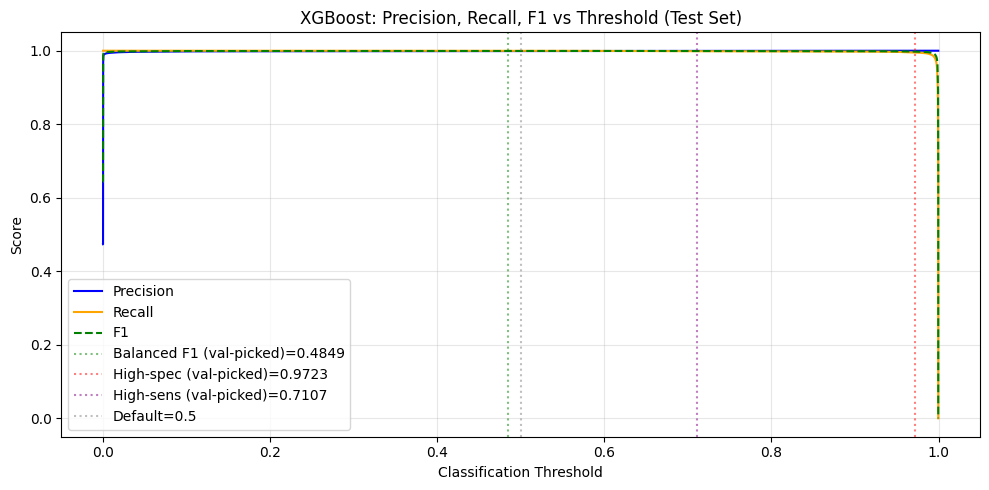

In [32]:
precisions, recalls, thresholds = precision_recall_curve(y_test, test_prob)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
 
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, precisions[:-1], label='Precision', color='blue')
ax.plot(thresholds, recalls[:-1],    label='Recall',    color='orange')
ax.plot(thresholds, f1_scores,       label='F1', color='green', linestyle='--')
ax.axvline(balanced_val,  color='green', alpha=0.5, linestyle=':',
           label=f'Balanced F1 (val-picked)={balanced_val:.4f}')
ax.axvline(high_spec_val, color='red',   alpha=0.5, linestyle=':',
           label=f'High-spec (val-picked)={high_spec_val:.4f}')
ax.axvline(high_sens_val, color='purple', alpha=0.5, linestyle=':',
           label=f'High-sens (val-picked)={high_sens_val:.4f}')
ax.axvline(0.5, color='gray', alpha=0.5, linestyle=':', label='Default=0.5')
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Score')
ax.set_title('XGBoost: Precision, Recall, F1 vs Threshold (Test Set)')
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('xgb_threshold_sweep.png', dpi=150)
plt.show()

### SHAP analysis

In [33]:
import shap

explainer = shap.TreeExplainer(baseline)
 
rng = np.random.RandomState(42)
shap_sample_size = min(5000, len(X_test))
shap_idx = rng.choice(len(X_test), size=shap_sample_size, replace=False)
X_shap = X_test[shap_idx]
 
shap_values = explainer.shap_values(X_shap)
print(f"SHAP values computed: {shap_values.shape}")

SHAP values computed: (5000, 95)


In [34]:
# Global Feature Importance
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_imp = (
    pd.Series(mean_abs_shap, index=feature_cols)
    .sort_values(ascending=False)
)
print("Top 20 features by mean |SHAP|:")
print(shap_imp.head(20))
 
# Compare to gain-based ranking.
gain_imp = pd.Series(baseline.feature_importances_, index=feature_cols)
comparison = pd.DataFrame({
    'shap_rank': shap_imp.rank(ascending=False).astype(int),
    'gain_rank': gain_imp.rank(ascending=False).astype(int),
    'mean_abs_shap': shap_imp,
    'gain': gain_imp,
}).sort_values('shap_rank').head(15)
print("\nSHAP vs gain ranking (top 15 by SHAP):")
print(comparison.to_string())

Top 20 features by mean |SHAP|:
pb_sb_over_non_ba_mass    4.088896
pb                        1.227758
sb                        1.023510
gsr_over_confounders      0.617380
ba_sb_over_non_pb_mass    0.452044
ba                        0.211337
pb_times_sb               0.158598
al                        0.078483
cu_zn_over_mass           0.043934
cu                        0.032444
s                         0.031084
fe                        0.026756
hg                        0.024902
as                        0.020969
ti_zn_over_mass           0.017647
k                         0.015152
si                        0.014477
zn                        0.012288
ti                        0.010327
o                         0.010322
dtype: float32

SHAP vs gain ranking (top 15 by SHAP):
                        shap_rank  gain_rank  mean_abs_shap      gain
pb_sb_over_non_ba_mass          1          1       4.088896  0.642439
pb                              2          2       1.227758  0.129808
sb 

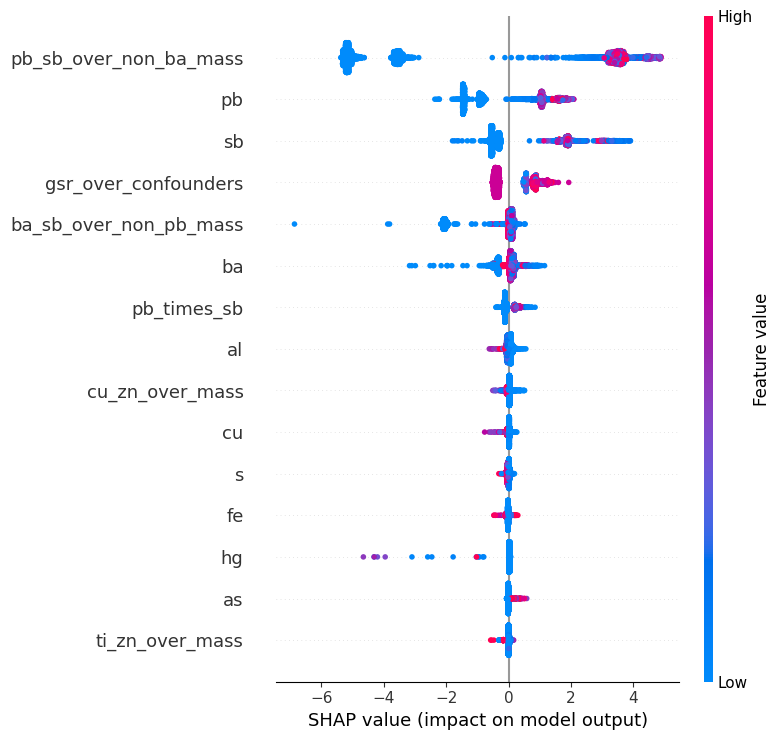

In [35]:
# SHAP summary plot
shap.summary_plot(
    shap_values, X_shap,
    feature_names=feature_cols,
    max_display=15,
    show=False,
)
plt.tight_layout()
plt.savefig('xgb_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

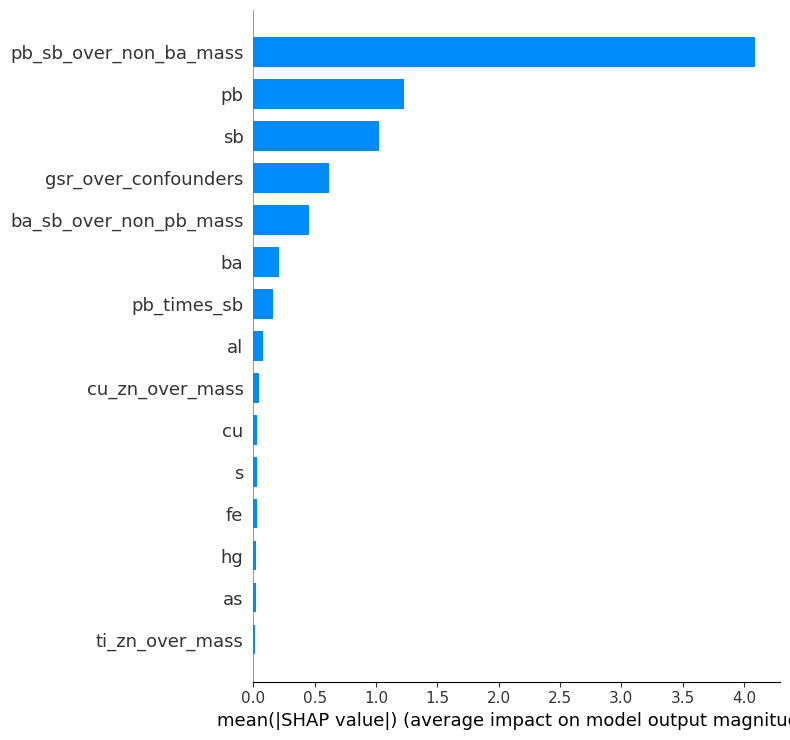

In [36]:
shap.summary_plot(
    shap_values, X_shap,
    feature_names=feature_cols,
    plot_type='bar',
    max_display=15,
    show=False,
)
plt.tight_layout()
plt.savefig('xgb_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
# Per-particle SHAP attribution for the false positives.
# For each FP, the top 3 features pushing toward GSR are listed
fp_indices_full = np.where(fp_mask)[0]
print(f"Computing SHAP for {len(fp_indices_full)} false positives...")
 
shap_fp = explainer.shap_values(X_test[fp_indices_full])
 
df_test_full = eng_df.iloc[test_idx].reset_index(drop=True)
fp_records = []
for i, idx in enumerate(fp_indices_full):
    row = df_test_full.iloc[idx]
    contributions = pd.Series(shap_fp[i], index=feature_cols)
    # Top 3 features pushing prediction toward GSR (positive SHAP).
    top_pos = contributions.nlargest(3)
    fp_records.append({
        'stub_id': row['stub_id'],
        'particle_id': row['particle_id'],
        'class': row['class'],
        'prob': test_prob[idx],
        'top_feature_1': top_pos.index[0],
        'shap_1': top_pos.iloc[0],
        'top_feature_2': top_pos.index[1],
        'shap_2': top_pos.iloc[1],
        'top_feature_3': top_pos.index[2],
        'shap_3': top_pos.iloc[2],
    })
fp_shap_df = pd.DataFrame(fp_records).sort_values('prob', ascending=False)
print("\nTop-15 highest-confidence FPs with SHAP attribution:")
print(fp_shap_df.head(15).to_string(index=False))
fp_shap_df.to_csv('xgb_fp_shap_attribution.csv', index=False)
 
# Aggregate: which features most often drive FPs?
fp_top_feature_counts = fp_shap_df['top_feature_1'].value_counts()
print(f"\nWhich features most often drive FPs (top-1 SHAP):")
print(fp_top_feature_counts.head(10))

Computing SHAP for 207 false positives...

Top-15 highest-confidence FPs with SHAP attribution:
 stub_id  particle_id  class     prob          top_feature_1   shap_1          top_feature_2   shap_2        top_feature_3   shap_3
     375         6058 BaCaSi 0.998979 pb_sb_over_non_ba_mass 4.601426                     pb 1.968737 gsr_over_confounders 1.017260
     803         4703   BaAl 0.998513                     sb 3.744666 pb_sb_over_non_ba_mass 2.188762 gsr_over_confounders 1.028491
     911         2455 BaCaSi 0.997288 pb_sb_over_non_ba_mass 3.411836   gsr_over_confounders 1.249357                   pb 0.859543
    1207         2699   BaAl 0.995232 pb_sb_over_non_ba_mass 4.429936                     pb 1.836542 gsr_over_confounders 0.929395
    2085         2621 BaCaSi 0.994278 pb_sb_over_non_ba_mass 3.295396   gsr_over_confounders 1.150988                   pb 0.918077
    1352         1647 BaCaSi 0.994166 pb_sb_over_non_ba_mass 3.069850   gsr_over_confounders 1.195662           

### Per-Tree Variance (XGB Uncertainty)

In [38]:
best_iter = baseline.best_iteration
# Sample prediction trajectories at evenly-spaced rounds late in training.
# Using late rounds (after the model has stabilized) avoids picking up
# early-training noise.
sample_rounds = np.linspace(
    max(1, best_iter // 2), best_iter, num=20, dtype=int
)
sample_rounds = np.unique(sample_rounds)
print(f"Sampling predictions at rounds: {sample_rounds.tolist()}")
 
prob_trajectories = np.zeros((len(sample_rounds), len(X_test)))
for i, k in enumerate(sample_rounds):
    prob_trajectories[i] = baseline.predict_proba(
        X_test, iteration_range=(0, int(k))
    )[:, 1]
 
mean_pred = prob_trajectories.mean(axis=0)
std_pred  = prob_trajectories.std(axis=0)
 
print(f"\nPrediction stability across late boosting rounds:")
print(f"  Mean std : {std_pred.mean():.6f}")
print(f"  Max std  : {std_pred.max():.6f}")
print(f"  Particles with std > 0.05 : {(std_pred > 0.05).sum():,} "
      f"({(std_pred > 0.05).mean():.2%})")
print(f"  Particles with std > 0.10 : {(std_pred > 0.10).sum():,} "
      f"({(std_pred > 0.10).mean():.2%})")

Sampling predictions at rounds: [34, 35, 37, 39, 41, 43, 45, 46, 48, 50, 52, 54, 56, 57, 59, 61, 63, 65, 67, 69]

Prediction stability across late boosting rounds:
  Mean std : 0.004884
  Max std  : 0.221370
  Particles with std > 0.05 : 225 (0.05%)
  Particles with std > 0.10 : 59 (0.01%)


In [39]:
print(f"{'Class':>10} {'Label':>8} {'N':>8} {'Mean Std':>10} "
      f"{'Max Std':>10} {'Std>0.05':>10}")
for cls in sorted(np.unique(test_classes)):
    mask = test_classes == cls
    n = mask.sum()
    if n < 10:
        continue
    label = test_labels[mask][0]
    cls_std = std_pred[mask]
    print(f"{cls:>10} {label:>8} {n:>8} {cls_std.mean():>10.6f} "
          f"{cls_std.max():>10.6f} {(cls_std > 0.05).sum():>10,}")

     Class    Label        N   Mean Std    Max Std   Std>0.05
      BaAl  Non_GSR    65221   0.005026   0.221370        112
    BaCaSi  Non_GSR    81503   0.004729   0.175091         33
      BaSb      GSR    20708   0.005533   0.121073         10
      CuZn  Non_GSR    75472   0.004721   0.128461         18
    GaCuSn  Non_GSR      426   0.004664   0.005193          0
        Hg  Non_GSR      678   0.006495   0.032117          0
      PbBa      GSR    48129   0.005137   0.140835         42
    PbBaSb      GSR   108047   0.004794   0.063746          2
      PbSb      GSR    33065   0.004851   0.072622          5
    TiZnGd  Non_GSR     3434   0.004727   0.073464          2
      ZnTi  Non_GSR     6541   0.004941   0.087270          1


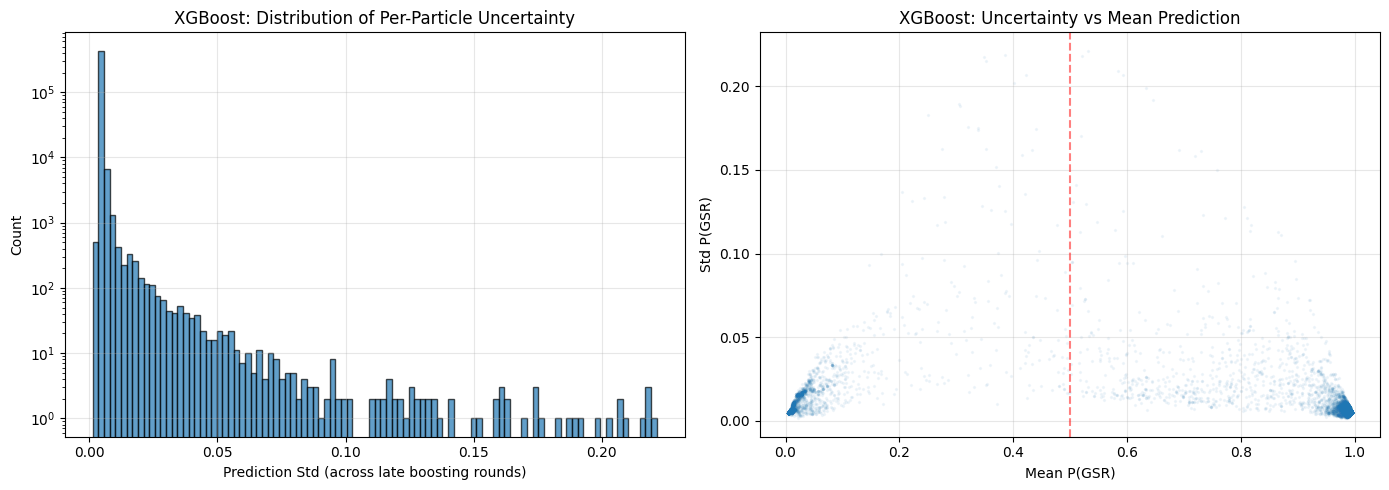

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(std_pred, bins=100, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Prediction Std (across late boosting rounds)')
axes[0].set_ylabel('Count')
axes[0].set_title('XGBoost: Distribution of Per-Particle Uncertainty')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)
 
axes[1].scatter(mean_pred, std_pred, alpha=0.05, s=2)
axes[1].set_xlabel('Mean P(GSR)')
axes[1].set_ylabel('Std P(GSR)')
axes[1].set_title('XGBoost: Uncertainty vs Mean Prediction')
axes[1].axvline(0.5, color='red', linestyle='--', alpha=0.5)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('xgb_uncertainty.png', dpi=150)
plt.show()

In [41]:
fp_std = std_pred[fp_mask]
tn_std = std_pred[(y_pred_test == 0) & (y_test == 0)]
print(f"FP particles : mean std = {fp_std.mean():.6f}, "
      f"median = {np.median(fp_std):.6f}")
print(f"TN particles : mean std = {tn_std.mean():.6f}, "
      f"median = {np.median(tn_std):.6f}")
print(f"Ratio        : {fp_std.mean() / max(tn_std.mean(), 1e-12):.1f}x")

FP particles : mean std = 0.031532, median = 0.021030
TN particles : mean std = 0.004797, median = 0.004671
Ratio        : 6.6x


# Ambiguous Particles

In [42]:
nfi_df = pd.read_parquet("../../../data/raw/NFI/nfi_particle_data_full.parquet")
nfi_df.shape

(2801667, 106)

In [43]:
nfi_df['merged_relevance_class'].unique()

<ArrowStringArray>
[    'PbSb',   'PbSbBa',       'Sb',       'Pb',     'PbBa',     'BaSb',
       'Ba',     'CuZn',   'BaCaSi',     'BaAl',       'Sr',     'ZnTi',
   'TiZnGd',       'Hg',     'BaSn',     'SbHg', 'PbSbBaSn',   'GaCuSn',
 'PbSbBaSr']
Length: 19, dtype: str

In [44]:
element_cols = [c for c in nfi_df.columns if 1 <= len(c) <= 2]
filtered = nfi_df[['stub_id', 'particle_id', 'merged_relevance_class'] + element_cols]
filtered = filtered.drop(columns='id')  # remove 'id' if it was included
element_cols = [c for c in filtered.columns if 1 <= len(c) <= 2]
len(element_cols)

89

In [45]:
amb_89 = filtered[filtered['merged_relevance_class'].isin(['Sb', 'Pb', 'Ba', 'Sr', 'BaSi', 'BaSn', 'BaSr'])]
amb_89.shape

(506682, 92)

In [46]:
amb_89 = (
    amb_89
    .rename(columns={'merged_relevance_class': 'final_class'})
    .assign(final_class=lambda d: d['final_class'].replace({'BaSn': 'Ba'}))
)

print(amb_89["final_class"].value_counts())

final_class
Sb    225676
Pb    168334
Ba     89277
Sr     23395
Name: count, dtype: int64


In [47]:
amb_89['label'] = 'Ambiguous'

In [48]:
df_amb = pd.read_parquet("../../../data/processed/particle_ambiguous.parquet")
print(f"Ambiguous particles: {len(df_amb):,}")
print(f"Class distribution:")
print(df_amb["final_class"].value_counts())

Ambiguous particles: 506,682
Class distribution:
final_class
Sb    225676
Pb    168334
Ba     89277
Sr     23395
Name: count, dtype: int64


__Rejoin original ambiguous dataset w/ preprocessed ambiguous dataset (all 89 elements)__

In [49]:
keys = ['stub_id', 'particle_id']
drop_extra = ['relevance_class', 'merged_relevance_class']

# columns in df_amb that overlap with amb_89 (other than the keys) -> drop from df_amb to avoid dupes
overlap = [c for c in df_amb.columns if c in amb_89.columns and c not in keys]
df_amb_trim = df_amb.drop(columns=overlap)

merged = amb_89.merge(df_amb_trim, on=keys, how='inner')
merged = merged.drop(columns=[c for c in drop_extra if c in merged.columns])
print(f"Merged dataset shape: {merged.shape}")

Merged dataset shape: (506682, 93)


In [50]:
amb_meta_cols = ['stub_id', 'particle_id', 'final_class', 'label']
amb_element_cols = [c for c in merged.columns if c not in amb_meta_cols]
len(amb_element_cols)

89

In [51]:
eng_amb = merged.copy()

In [52]:
# Pb * Sb
eng_amb['pb_times_sb'] = eng_amb['pb'] * (eng_amb['sb'])

In [53]:
# Log (Pb + Sb)
# eng_amb['log_pb_plus_sb'] = np.log1p(eng_amb['pb'] + eng_amb['sb'])

In [54]:
# GSR ratios over total mass
total_mass = eng_amb[element_cols].sum(axis=1)
total_mass_no_sb = total_mass - eng_amb['sb']
total_mass_no_ba = total_mass - eng_amb['ba']
total_mass_no_pb = total_mass - eng_amb['pb']

# eng_amb['pb_ba_over_non_sb_mass'] = (eng_amb['pb'] + eng_amb['ba']) / total_mass_no_sb
eng_amb['pb_sb_over_non_ba_mass'] =  (eng_amb['pb'] + eng_amb['sb']) / total_mass_no_ba
eng_amb['ba_sb_over_non_pb_mass'] =  (eng_amb['ba'] + eng_amb['sb']) / total_mass_no_pb

In [55]:
# Brass particles
eng_amb['cu_zn_over_mass'] =  (eng_amb['cu'] + eng_amb['zn']) / total_mass

# Titanium Zinc
eng_amb['ti_zn_over_mass'] = (eng_amb['ti'] + eng_amb['zn']) / total_mass

In [56]:
# Non-Barium GSR over Non-Barium Confounders
gsr = eng_amb['pb'] + eng_amb['sb']
confounders = eng_amb['ca'] + eng_amb['si'] + eng_amb['al'] + eng_amb['fe'] #+ eng_amb['ti'] + eng_amb['zn'] + eng_amb['cu']
eng_amb['gsr_over_confounders'] = sentinel_divide(gsr.values, confounders.values)

# check for any 'NaN' or 'inf'
any(np.isinf(eng_amb['gsr_over_confounders']) | eng_amb['gsr_over_confounders'].isna())

False

In [57]:
eng_amb.columns

Index(['stub_id', 'particle_id', 'final_class', 'ac', 'ag', 'al', 'ar', 'as',
       'at', 'au', 'b', 'ba', 'bi', 'br', 'ca', 'cd', 'ce', 'cl', 'co', 'cr',
       'cs', 'cu', 'dy', 'er', 'eu', 'f', 'fe', 'fr', 'ga', 'gd', 'ge', 'hf',
       'hg', 'ho', 'i', 'in', 'ir', 'k', 'kr', 'la', 'lu', 'mg', 'mn', 'mo',
       'n', 'na', 'nb', 'nd', 'ne', 'ni', 'np', 'o', 'os', 'p', 'pa', 'pb',
       'pd', 'pm', 'po', 'pr', 'pt', 'pu', 'ra', 'rb', 're', 'rh', 'rn', 'ru',
       's', 'sb', 'sc', 'se', 'si', 'sm', 'sn', 'sr', 'ta', 'tb', 'tc', 'te',
       'th', 'ti', 'tl', 'tm', 'u', 'v', 'w', 'xe', 'y', 'yb', 'zn', 'zr',
       'label', 'pb_times_sb', 'pb_sb_over_non_ba_mass',
       'ba_sb_over_non_pb_mass', 'cu_zn_over_mass', 'ti_zn_over_mass',
       'gsr_over_confounders'],
      dtype='str')

In [58]:
eng_amb_cols = [c for c in eng_amb.columns if c not in amb_meta_cols + amb_element_cols]
print(f"# of engineered features: {len(eng_amb_cols)}")
print(f"\nEngineered features:")
for feat in eng_amb_cols:
    print(f"\t{feat}")

# of engineered features: 6

Engineered features:
	pb_times_sb
	pb_sb_over_non_ba_mass
	ba_sb_over_non_pb_mass
	cu_zn_over_mass
	ti_zn_over_mass
	gsr_over_confounders


__6 engineered features + 89 raw element features__

In [59]:
feature_amb_cols = amb_element_cols + eng_amb_cols
print(f"# of feature columns: {len(feature_amb_cols)}")

# of feature columns: 95


### Run Model against Ambiguous Particles

In [60]:
model = baseline

In [ ]:
X_amb = eng_amb[feature_amb_cols].values.astype(np.float32)

probs_amb = model.predict_proba(X_amb)[:, 1]
preds_amb = (probs_amb >= 0.97).astype(int)

eng_amb = eng_amb.assign(prob_gsr=probs_amb, pred_gsr=preds_amb)

n = len(eng_amb)
n_gsr = int(preds_amb.sum())
print(f'Particles scored : {n:,}')
print(f'Predicted GSR    : {n_gsr:,}  ({n_gsr / n:.1%})')
print(f'Predicted Non-GSR: {n - n_gsr:,}  ({1 - n_gsr / n:.1%})')
print(f'\nProbability distribution:')
print(pd.Series(probs_amb).describe(percentiles=[.1, .25, .5, .75, .9, .95]).round(4))
print(f'\nPredicted GSR by final_class:')
agg = (
    eng_amb.groupby('final_class')
           .agg(n=('pred_gsr', 'size'),
                pred_gsr=('pred_gsr', 'sum'),
                mean_prob=('prob_gsr', 'mean'))
)
agg['pct_gsr'] = agg['pred_gsr'] / agg['n'] * 100
agg = agg.sort_values('pct_gsr', ascending=False)
print(agg.round(2))

Particles scored : 506,682
Predicted GSR    : 1,454  (0.3%)
Predicted Non-GSR: 505,228  (99.7%)

Probability distribution:
count    506682.0000
mean          0.2827
std           0.3503
min           0.0004
10%           0.0005
25%           0.0039
50%           0.0411
75%           0.6840
90%           0.8594
95%           0.8768
max           0.9995
dtype: float64

Predicted GSR by final_class:
                  n  pred_gsr  mean_prob  pct_gsr
final_class                                      
Pb           168334       780       0.07     0.46
Ba            89277       239       0.01     0.27
Sb           225676       435       0.58     0.19
Sr            23395         0       0.00     0.00


In [62]:
print(f'Overall pct_gsr (manual): {eng_amb["pred_gsr"].mean() * 100:.2f}%')
print(f'Weighted from agg:        {(agg["pred_gsr"].sum() / agg["n"].sum()) * 100:.2f}%')
print(agg[["n", "pred_gsr", "pct_gsr"]])

Overall pct_gsr (manual): 0.29%
Weighted from agg:        0.29%
                  n  pred_gsr   pct_gsr
final_class                            
Pb           168334       780  0.463365
Ba            89277       239  0.267706
Sb           225676       435  0.192754
Sr            23395         0  0.000000


__9% of Sb particles predicted as GSR ... Wow ...__

In [63]:
sb_mask = (eng_amb['final_class'] == 'Sb')
sb_flagged = eng_amb[sb_mask & (eng_amb['pred_gsr'] == 1)]
sb_not_flagged = eng_amb[sb_mask & (eng_amb['pred_gsr'] == 0)]

# Compare elemental compositions
print(sb_flagged[element_cols].describe())
print(sb_not_flagged[element_cols].describe())

# Are these "purely Sb" or do they have trace other elements?
sb_flagged['n_elements'] = (sb_flagged[element_cols] > 0).sum(axis=1)
print(sb_flagged['n_elements'].value_counts())

          ac     ag          al     ar          as     at     au      b  \
count  435.0  435.0  435.000000  435.0  435.000000  435.0  435.0  435.0   
mean     0.0    0.0    1.945828    0.0    0.003059    0.0    0.0    0.0   
std      0.0    0.0    3.147482    0.0    0.040396    0.0    0.0    0.0   
min      0.0    0.0    0.000000    0.0    0.000000    0.0    0.0    0.0   
25%      0.0    0.0    0.000000    0.0    0.000000    0.0    0.0    0.0   
50%      0.0    0.0    0.863801    0.0    0.000000    0.0    0.0    0.0   
75%      0.0    0.0    2.027686    0.0    0.000000    0.0    0.0    0.0   
max      0.0    0.0   21.988396    0.0    0.718500    0.0    0.0    0.0   

               ba          bi  ...     tl     tm      u           v      w  \
count  435.000000  435.000000  ...  435.0  435.0  435.0  435.000000  435.0   
mean     0.334456    0.041222  ...    0.0    0.0    0.0    0.000539    0.0   
std      0.449203    0.663470  ...    0.0    0.0    0.0    0.011238    0.0   
min      0.0

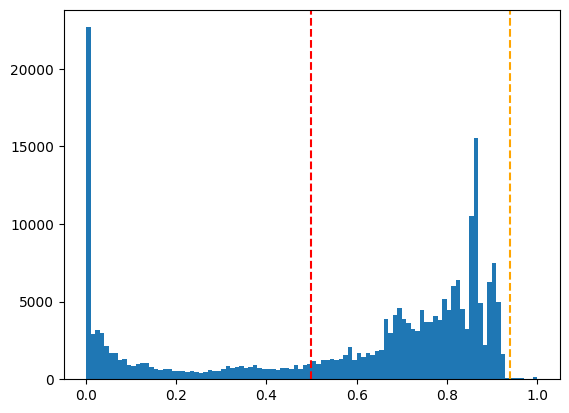

In [64]:
sb_probs = probs_amb[sb_mask]
plt.hist(sb_probs, bins=100)
plt.axvline(0.5, color='red', linestyle='--')
plt.axvline(0.94, color='orange', linestyle='--', label='your threshold')

In [65]:
sb_flagged_idx = np.where(sb_mask & (preds_amb == 1))[0]
sample_idx = np.random.choice(sb_flagged_idx, 500, replace=False)
X_sb_flagged = X_amb[sample_idx]

explainer = shap.TreeExplainer(baseline)

shap_values_sb = explainer.shap_values(X_sb_flagged)
shap.summary_plot(shap_values_sb, X_sb_flagged, feature_names=feature_amb_cols)

ValueError: Cannot take a larger sample than population when 'replace=False'

In [ ]:
sb_flagged.groupby('stub_id').size().describe()
sb_flagged['stub_id'].value_counts().head(20)

stub_id
1059    769
2366    648
2027    644
3524    505
3853    452
2455    414
1645    339
3913    324
232     297
1137    275
344     273
530     271
2724    267
1836    264
761     258
62      231
2166    220
2549    214
1290    210
3337    208
Name: count, dtype: int64